# SHIFTS IN THE BEATLES' LANGUAGE USE ACROSS THEIR STUDIO ALBUMS

    By: An Nguyen

    May 4, 2026

## Introduction

I am analyzing the evolution of the Beatles' lyrics across their entire studio catalog using Genius API. 

The band's had a long career, and they've cemented themselves as the most important band of all time (not an opinion). I'm curious to see how much the Beatles evolved throughout their time as a quartet. For simplicity, I'm going to strictly adhere to the official canon. I will be excluding any compilation albums, re-releases, special editions, deluxes, SUPER deluxes, movie soundtracks lacking in significant original songs (sorry to Yellow Submarine), etc. Is this entire notebook just an excuse for me to finally listen to the Beatles' discography? Perchance.  

I'll be tracking these following albums: 
* Please Please Me
* With The Beatles
* A Hard Day's Night
* Beatles For Sale
* Help!
* Rubber Soul
* Revolver
* Sgt. Pepper's Lonely Hearts Club Band
* Magical Mystery Tour
* The Beatles (White Album)
* Abbey Road
* Let It Be

A (tentative) list of what I'm going to be going over:

* TTR: What is the lexical diversity in the Beatles' discography?
* tf-idf: What's the distinctiveness like in the Beatles' discography?
* How does the semantic meanings evolve throughout the Beatles' discography?
* How does tf-idf and word embeddings, plotted together, tell us about the Beatles' canon albums?
* Are there any interesting songs that can individually exemplify the patterns and relationships we see in the Beatles' language use over time?

For starters, I need to nab all 12 of the Beatles' studio albums from GeniusAPI, and import the necessary elements I'll need. 

In [92]:
%%time
import Constants
token = Constants.API_KEY

import lyricsgenius
import os
import time
from collections import Counter
import re
import numpy as np

from collections import Counter
import re

from sklearn.cluster import KMeans
import pandas as pd


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from IPython.display import YouTubeVideo

CPU times: user 52 μs, sys: 294 μs, total: 346 μs
Wall time: 358 μs


(spacy used later for word embeddings.)

In [2]:
# !pip install spacy
# !python -m spacy download en_core_web_md

### Testing (Warm-Up)
This is where I'm getting comfortable, and testing out some stuff before I actually start doing things like building the corpus.

In [ ]:
genius = lyricsgenius.Genius(token, timeout = 20, retries = 3)
genius.sleep_time = 2

artist = genius.search_artist("The Beatles",max_songs = 13,get_full_info=True)

In [ ]:
artist.songs
# artist.songs[0].to_text()

In [ ]:
song_dict = dict()

for song in artist.songs:
    song_dict[song.title] = song.to_text()

song_dict['Hey Jude']

In [ ]:
song_dict = dict()

for song in artist.songs:
    song_dict[song.title] = song.to_text()

In [ ]:
albums = genius.search_album(name="A Hard Day\s Night", artist = 'The Beatles')

In [ ]:
albums = genius.search_album(name="Revolver", artist = 'The Beatles')

## Corpus Construction
I am going to construct the corpus of all the Beatles' albums together. I'll need to include every non-instrumental song per album together. 

In [45]:
albums = ["Please Please Me", 
          "With The Beatles", 
          "A Hard Day’s Night", 
          "Beatles For Sale", 
          "Help!", "Rubber Soul", 
          "Revolver", 
          "Sgt. Pepper’s Lonely Hearts Club Band", 
          "Magical Mystery Tour", "The Beatles", 
          "Abbey Road", "Let It Be"]

len(albums)

12

Do you know what's helpful? Being a bigger Beatles fan and listening to all the albums beforehand. This would prevent wasting more than a day of work before realizing 'Flying' from Magical Mystery is pure instrumental and needs to be excluded. 

In [ ]:
expected_tracks = {
    "Please Please Me": [
        "I Saw Her Standing There", "Misery", "Anna (Go to Him)", "Chains",
        "Boys", "Ask Me Why", "Please Please Me", "Love Me Do",
        "P.S. I Love You", "Baby It’s You", "Do You Want to Know a Secret",
        "A Taste of Honey", "There’s a Place", "Twist and Shout"
    ],
    "With The Beatles": ["It Won’t Be Long", "All I’ve Got To Do", "All My Loving", "Don’t Bother Me", "Little Child",
                        "Till There Was You", "Please Mister Postman", "Roll Over Beethoven", "Hold Me Tight", "You Really Got A Hold On Me",
                        "I Wanna Be Your Man", "Devil in Her Heart", "Not A Second Time", "Money (That’s What I Want"
                        ],
    "A Hard Day’s Night": [
        "A Hard Day’s Night", "I Should Have Known Better", "If I Fell",
        "I’m Happy Just To Dance With You", "And I Love Her", "Tell Me Why",
        "Can’t Buy Me Love", "Any Time At All", "I’ll Cry Instead", "Things We Said Today",
        "When I Get Home", "You Can’t Do That", "I’ll Be Back"
    ],
    "Beatles For Sale": [
        "No Reply", "I’m A Loser", "Baby’s In Black", "Rock And Roll Music", "I’ll Follow The Sun", "Mr. Moonlight", 
        "Kansas City/Hey-Hey-Hey-Hey!", "Eight Days A Week", "Words Of Love", "Honey Don’t", "Every Little Thing", 
        "I Don’t Want To Spoil The Party", "What You’re Doing", "Everybody’s Trying To Be My Baby"
    ],
    "Help!": [
        "Help!", "The Night Before", "You’ve Got To Hide Your Love Away", "I Need You", "Another Girl", 
        "You’re Going To Lose That Girl", "Ticket To Ride", "Act Naturally", "It’s Only Love", "You Like Me Too Much",
        "Tell Me What You See", "Yesterday", "Dizzy Miss Lizzy"
             ],

    # im going to lose myself... 

    "Rubber Soul": [
        "Drive My Car", "Norwegian Wood (This Bird Has Flown)", "You Won’t See Me", "Nowhere Man", "Think For Yourself",
        "The Word", "Michelle", "What Goes On", "Girl", "I’m Looking Through You", "In My Life", "Wait", 
        "If I Needed Someone", "Run For Your Life"
    ],

    "Revolver": ["Taxman", "Eleanor Rigby", "I’m Only Sleeping", "Love You To", "Here, There, and Everywhere",
                 "Yellow Submarine", "She Said She Said", "Good Day Sunshine", "And Your Bird Can Sing", "For No One", 
                 "Doctor Robert", "I Want To Tell You", "Got To Get You Into My Life", "Tomorrow Never Knows"
                ],    

    "Sgt. Pepper’s Lonely Hearts Club Band": [
        "Sgt. Pepper’s Lonely Hearts Club Band", "With a Little Help from My Friends",
        "Lucy in the Sky with Diamonds", "Getting Better", "Fixing a Hole",
        "She’s Leaving Home", "Being for the Benefit of Mr. Kite!",
        "Within You Without You", "When I’m Sixty-Four", "Lovely Rita",
        "Good Morning Good Morning", "Sgt. Pepper’s Lonely Hearts Club Band (Reprise)",
        "A Day in the Life"
    ],
    "Magical Mystery Tour": [
        "Magical Mystery Tour", "The Fool On The Hill", "Blue Jay Way", "Your Mother Should Know", "I Am The Walrus",
        "Hello, Goodbye", "Strawberry Fields Forever", "Penny Lane", "Baby, You’re A Rich Man", "All You Need Is Love" 
        
    ],
    "The Beatles (White Album)": [
        "Back In The U.S.S.R.", "Dear Prudence", "Glass Onion", "Ob-La-Di, Ob-La-Da", "Wild Honey Pie", 
        "The Continuing Story of Bungalow Bill", "While My Guitar Gently Weeps", "Happiness Is A Warm Gun",
        "Martha My Dear", "I’m So Tired", "Blackbird", "Piggies", "Rocky Raccoon", "Don’t Pass Me By", 
        "Why Don’t We Do It In The Road", "I Will", "Julia", "Birthday", "Yer Blues", "Mother Nature’s Son",
        "Everybody’s Got Something To Hide Except Me And My Monkey", "Sexy Sadie", "Helter Skelter", "Long, Long, Long", 
        "Revolution 1", "Honey Pie", "Savoy Truffle", "Cry Baby Cry", "Revolution 9", "Good Night"
    ],
    "Abbey Road": [
       "Come Together", "Something", "Maxwell’s Silver Hammer", "Oh! Darling", "Octopus’s Garden", 
        "I Want You (She’s So Heavy)", "Here Comes The Sun", "Because", "You Never Give Me Your Money", "Sun King",
        "Mean Mr. Mustard", "Polythene Pam", "She Came In Through The Bathroom Window", "Golden Slumbers", "Carry That Weight",
        "The End", "Her Majesty"
    ],
    "Let It Be": ["Two Of Us", "Dig A Pony", "Across The Universe", "I Me Mine", "Dig It", "Let It Be", "Maggie Mae", 
                  "I’ve Got A Feeling", "One After 909", "The Long And Winding Road", "For You Blue", "Get Back"
        
    ]
}

songs = []
for album_name, tracklist in expected_tracks.items():
    for title in tracklist:
        song = genius.search_song(title, artist = "The Beatles")
        if song: 
            songs.append((album_name, song))
            print(f"Found: {song.title}")
        else:
            print(f"Not Found: {song.title}")


I do not want to constantly run the above cell and wait an erroneous amount of time for all the songs to load, so I'm going to save it as a json file for convenience. 

In [ ]:
import json

songs_data = [(album_name, song.to_dict()) for album_name, song in songs]

with open("songs.json", "w") as f:
    json.dump(songs_data, f)

print("Saved!")

In [4]:
with open("songs.json", "r") as f:
    songs_data = json.load(f)

print(f"Loaded the {len(songs_data)} songs")

Loaded the 178 songs


## Stopwords Filtering

Now that I've finally constructed my corpus, I'm going to remove words that don't change much of the songs' core meanings, and do some regex to provide a cleaner slate for my analysis. I'm removing the band members' names, pronouns, and prepositions. Afterwards, we can see what are the top 10 most common words from each of their albums.

In [88]:
songs = [(album_name, song_dict) for album_name, song_dict in songs_data]

stopwords = {'paul', 'mccartney', 'john', 'lennon', 'george', 'harrison', 'ringo', 'starr', 
            'i', 'me', 'myself', 'you', 'yourself', 'your', 'he', 'she', 'his', 'her', 'him', 'it', 'its', 'we', 'us', 'our', 
            'they', 'them', 'their', 'this', 'a', 'the', 'that', 'thats', 'and', 'to', 'be', 'do', 'of', 'with', 'my', 'ive', 'in', 'is', 
             'im', 'ill', 'at', 'for', 'on'}



#regex, and cleaning lyric formats. 
def clean_lyrics(lyrics):
    lyrics = re.sub(r'\[.*?\]', '', lyrics) #remove lyrical structure headings. 
    lyrics = re.sub(r'[^a-zA-Z\s]', '', lyrics) #removing punctuation. 
    lyrics = re.sub(r'^\d+.*$', '', lyrics, flags = re.MULTILINE) #removing lines starting with numbers. 
    lyrics = lyrics.lower()
    words = [w for w in lyrics.split() if w not in stopwords]  # filter names
    return ' '.join(words)

album_word_freq = {}

for album_name, song in songs:
    if album_name not in album_word_freq:
        album_word_freq[album_name] = Counter()

    if song['lyrics']:
        cleaned_up = clean_lyrics(song['lyrics'])
        words = cleaned_up.split()
        album_word_freq[album_name].update(words)


for album_name, freq in album_word_freq.items():
    print(f"\n{album_name}\n")
    for word, count in freq.most_common(10):
        print(f" {word}: {count}")


Please Please Me

 love: 74
 yeah: 54
 come: 37
 know: 36
 boys: 30
 ah: 28
 now: 26
 baby: 26
 oh: 22
 girl: 22

With The Beatles

 yeah: 94
 want: 54
 no: 49
 oh: 44
 what: 42
 got: 38
 hold: 38
 dont: 30
 wanna: 29
 all: 28

A Hard Day’s Night

 love: 73
 when: 35
 cant: 35
 if: 33
 all: 32
 oh: 25
 time: 21
 things: 20
 so: 20
 tell: 19

Beatles For Sale

 bye: 56
 love: 48
 baby: 33
 dont: 32
 so: 29
 what: 28
 now: 27
 honey: 25
 ah: 20
 hey: 20

Help!

 girl: 45
 gonna: 43
 youre: 34
 dont: 31
 yes: 29
 now: 27
 lose: 26
 so: 25
 got: 24
 when: 21

Rubber Soul

 ooh: 106
 tit: 64
 la: 51
 girl: 42
 love: 29
 see: 27
 if: 26
 wont: 26
 word: 26
 what: 25

Revolver

 all: 43
 day: 34
 yellow: 27
 submarine: 27
 love: 24
 no: 23
 good: 23
 know: 23
 dont: 20
 what: 19

Sgt. Pepper’s Lonely Hearts Club Band

 tchic: 61
 better: 38
 ah: 27
 good: 27
 morning: 24
 all: 22
 from: 22
 so: 21
 will: 21
 could: 20

Magical Mystery Tour

 love: 95
 all: 75
 need: 65
 know: 42
 dont: 42
 s

## Type-Token Ratio
Now, I'd like to compute the Type-Token Ratio per album to see the Beatles' lexical diversity over time. 

In [89]:
ttr = {}
for album_name, freq in album_word_freq.items():
    total_tokens = sum(freq.values())
    total_types = len(freq)
    ttr[album_name] = total_types / total_tokens # divide the number of unique words (types) with total number of words (tokens). 

for album, score in ttr.items():
    print(f"{album}: {score}")

Please Please Me: 0.19732654360280077
With The Beatles: 0.18308351177730192
A Hard Day’s Night: 0.21181938911022577
Beatles For Sale: 0.23132969034608378
Help!: 0.21449970041941283
Rubber Soul: 0.22328042328042327
Revolver: 0.2979564930784443
Sgt. Pepper’s Lonely Hearts Club Band: 0.33014354066985646
Magical Mystery Tour: 0.2467895030709101
The Beatles (White Album): 0.26136078332914886
Abbey Road: 0.33135313531353133
Let It Be: 0.3036576949620428


#### TTR plotting

Now, we'll plot the lexical diversity. 

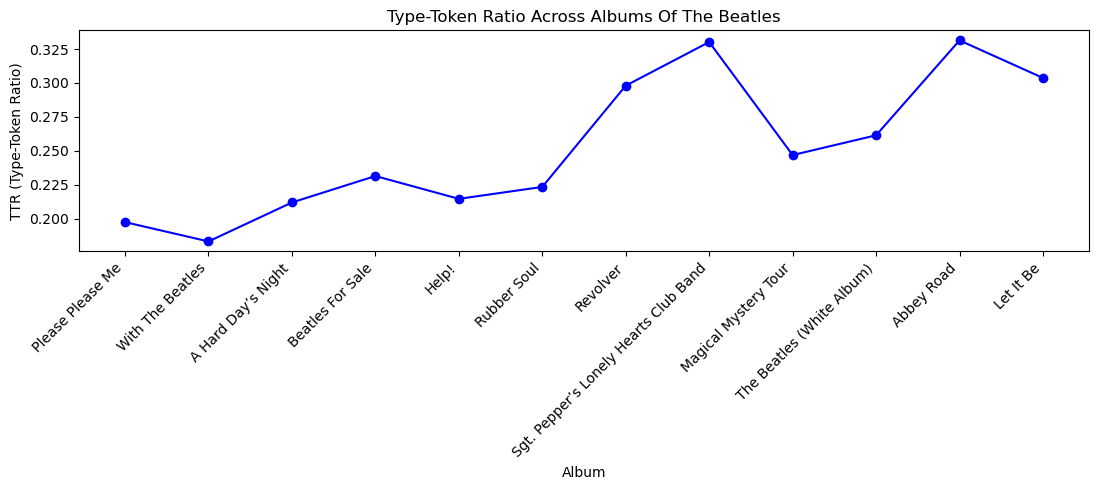

In [90]:
album_order = [
    "Please Please Me", "With The Beatles", "A Hard Day’s Night",
    "Beatles For Sale", "Help!", "Rubber Soul", "Revolver",
    "Sgt. Pepper’s Lonely Hearts Club Band", "Magical Mystery Tour",
    "The Beatles (White Album)", "Abbey Road", "Let It Be"
]

plt.figure(figsize=(11, 5))
plt.plot(album_order, [ttr[a] for a in album_order], marker='o', color = 'blue')
plt.xticks(rotation=45, ha='right')
plt.title("Type-Token Ratio Across Albums Of The Beatles")
plt.xlabel("Album")
plt.ylabel("TTR (Type-Token Ratio)")
plt.tight_layout()
plt.show()

##### *Observations*
Huh! Interesting. What we see hear is that the Early Beatles' albums (Please Please Me, With The Beatles) have the lowest Type-Token Ratio (TTR), so they're the most repetitive. TTR generally increases across their discography. Sgt. Pepper's hits the highest peak in lexical diversity alongside Abbey Road. Despite its experimentation, Magical Mystery Tour is shown to have a dip in TTR.

##### *Analysis*
The upward trend in TTR in the Beatles' discography provides support to the argument that the band's language became increasingly varied and lexically rich over time. The early albums' low TTR is consistent with the reliance on repetitive verse-chorus structures. The early Beatles' albums also contained many cover songs. 

The sharp rise starting in Revolver reflects the band's turn towards more ambitious songwriting; longer, more narratively-complex lyrics will draw on on a wider and more unusual vocabulary. 

Magical Mystery Tour's dip is worth noting. Despite its reputation for being one of the band's most experimental records, its TTR suggests heavier lyrical repetition (especially compared to Sgt. Pepper's). This suggests experimentation does not always correlate with lexical diversity. Overall, TTR shows that their vocabulary varied over time. 

## tf-idf Clustering 

The band's lexical diversity continously increases over time, but let's look at how uniquely distinct their albums are from each other through tf-idf. I'm going to perform tf-idf vectorization, then group the albums into clusters to investigate the distinctivenss of each album's language. 

Initially, I was going to do 3 clusters ('Early' Beatles, 'Middle' Beatles, 'Late' Beatles), but I found having 4 clusters instead was analytically more interesting. 

In [91]:
#combining all cleaned text lyrics into one string per album

print("Cleaned Word Counts")

album_texts = {}
for album_name, song in songs:
    if album_name not in album_texts:
        album_texts[album_name] = '' 
    if song['lyrics']:
        album_texts[album_name] += '' + clean_lyrics(song['lyrics'])

#checking if its working.
for album, text in album_texts.items():
    print(f"{album}: {len(text.split())} words ")
        

Cleaned Word Counts
Please Please Me: 1558 words 
With The Beatles: 1855 words 
A Hard Day’s Night: 1494 words 
Beatles For Sale: 1634 words 
Help!: 1657 words 
Rubber Soul: 1877 words 
Revolver: 1504 words 
Sgt. Pepper’s Lonely Hearts Club Band: 2078 words 
Magical Mystery Tour: 1782 words 
The Beatles (White Album): 3954 words 
Abbey Road: 1499 words 
Let It Be: 1438 words 


In [93]:
#tf-idf vectorization. 

from sklearn.feature_extraction.text import TfidfVectorizer

album_names = list(album_texts.keys())
album_docs = [album_texts[name] for name in album_names]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(album_docs)

X.shape


(12, 2594)

In [51]:
#clustering

#trying 4 clusters.
kmeans = KMeans(n_clusters = 4, random_state = 42)
clusters = kmeans.fit_predict(X)

cluster_df = pd.DataFrame({'Album': album_names, 'Cluster': clusters}).sort_values('Cluster')
cluster_df

,Album,Cluster
2,A Hard Day’s Night,0
3,Beatles For Sale,0
4,Help!,0
5,Rubber Soul,0
6,Revolver,0
9,The Beatles (White Album),0
7,Sgt. Pepper’s Lonely Hearts Club Band,1
0,Please Please Me,2
1,With The Beatles,2
10,Abbey Road,2


We have the first cluster (Cluster 0) grouping "A Hard Day's Night", "Beatles For Sale", "Help!", "Rubber Soul", "Revolver", and "The Beatles (White Album)" together. The 2nd cluster (Cluster 1) solely belongs to "Sgt. Pepper’s Lonely Hearts Club Band". Then, our third cluster (Cluster 2) includes "Please Please Me", "With The Beatles", "Abbey Road", and "Let It Be". Our last cluster (Cluster 3) belongs to the one and only weirdo, "Magical Mystery Tour". 

#### PCA Plotting
Let's visually look at the clusters. 

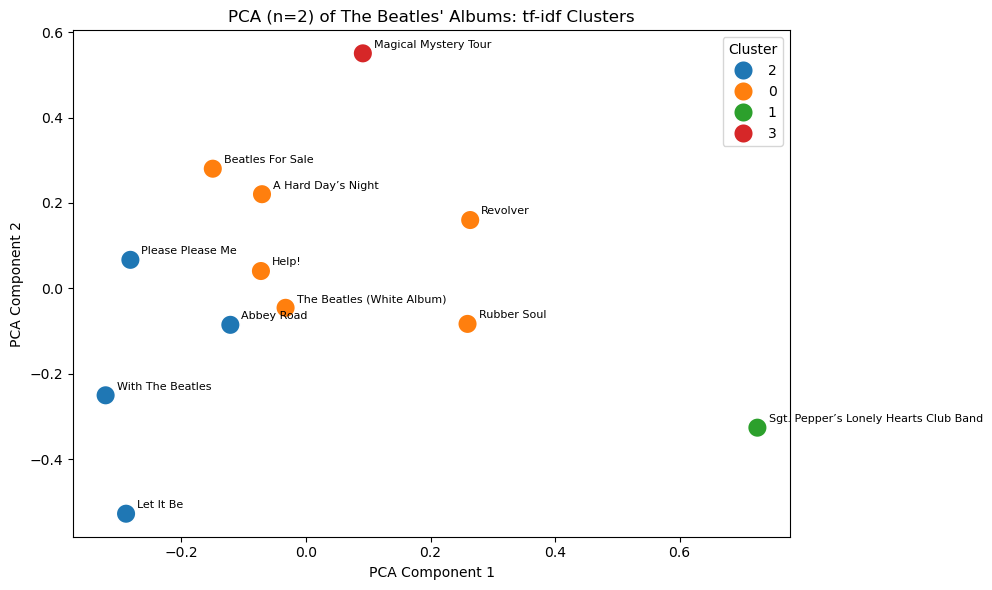

In [56]:
#PCA plotting

#2d reduction for pca
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

pca_df = pd.DataFrame({'Album': album_names, 'PCA1': reduced[:,0], 'PCA2': reduced[:,1], 'Cluster':clusters.astype(str)})

plt.figure(figsize=(10,6))

sns.scatterplot(data = pca_df, x= 'PCA1', y = 'PCA2', hue = 'Cluster', s = 200)

for idx, row in pca_df.iterrows():
    plt.annotate(row['Album'], (row['PCA1'], row['PCA2']), 
                 fontsize=8, xytext=(8, 4), textcoords='offset points')


plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA (n=2) of The Beatles' Albums: tf-idf Clusters")
plt.tight_layout()
plt.show()



##### *Observations:*
* Cluster 0 (orange cluster: Beatles For Sale, A Hard Day's Night, Help!, Revolver, The Beatles (White Album), Rubber Soul) cluster towards the middle.
* Cluster 1 (green cluster: Sgt. Pepper's Lonely Hearts Club Band) is an outlier on the right.
* Cluster 2 (blue cluster: Let It Be, With The Beatles, Abbey Road, Please Please Me) are all grouped on the left side of the plot.
* Cluster 3 (red cluster: Magical Mystery Tour) is extremely high and alone at the top of the plot.

Sgt. Pepper's is the most lexically distinct album. It sits far to the right, and it's completely seperated from every other album. Through tf-idf, we can interpret that this particular album uses vocabulary the most uniquely: words that appear in Sgt. Pepper's barely appear anywhere else in their catalog.

Magical Mystery Tour seems the second-most distinct album, high and alone. 

##### *Analysis:*
What the tf-idf plot shows is four groupings that reflect the Beatles' style evolution. 
Sgt Pepper's Lonely Hearts Club Band (Cluster 1) and Magical Mystery Tour (Cluster 3) emerge as isolated clusters. Both draw on surrealist, psychedelic vocabulary so unique that no other albums share enough terminology to cluster with them. 

Cluster 0 occupies the center: it includes their middle-period albums, and The White Album. The White Album's inclusion suggests that despite its double-album format, the album's vocabulary more closely represents their middle-career music output than their experimental peak.

Please Please Me, Let It Be, Abbey Road, and With The Beatles are grouped together: their first two albums and last two albums clustered together. This suggests that the Beatles returned to similar vocabulary that characterized their first recorded outputs. A full circle moment.

#### Word Embeddings: spaCy

After examining the Beatles' catalog through frequency-based metrics, how has their usage of words to convey meanings evolve over time? 

I'm choosing to include word embeddings for my project to capture that part of the Beatles' catalog; examining whether albums with different vocabulary share similar meanings and themes. However, I'm substituting gensim out with a pretrained model that I found would be better: spaCy. This is because my corpora size is too small for gensim to give me reliable results, and I do not want to be limited by corpora size. I acknowledge gensim would give me embeddings specific to the Beatles' language and how they used words, but I'm limited by the Beatles' canon albums; the model won't learn meaningful relationships anyways.

In [57]:
import spacy
nlp = spacy.load("en_core_web_md")

# Testing semantic similarity between two words.
word1 = nlp("love")
word2 = nlp("dream")
print(word1.similarity(word2))


0.5244521498680115


In [95]:
album_vectors = {}
for album_name, text in album_texts.items():
    doc = nlp(text[:1000000])  # spacy has a text length limit. doesn't really change anything with my project's corpus though. just don't wanna get flagged for it.
    album_vectors[album_name] = doc.vector  # averaging of all word vectors.

vector_matrix = np.array([album_vectors[a] for a in album_order])

kmeans_semantic = KMeans(n_clusters=4, random_state=42)
semantic_clusters = kmeans_semantic.fit_predict(vector_matrix)

semantic_df = pd.DataFrame({'Album': album_order,'Cluster': semantic_clusters}).sort_values('Cluster')

semantic_df


,Album,Cluster
2,A Hard Day’s Night,0
4,Help!,0
6,Revolver,1
7,Sgt. Pepper’s Lonely Hearts Club Band,1
9,The Beatles (White Album),1
10,Abbey Road,1
11,Let It Be,1
0,Please Please Me,2
1,With The Beatles,2
3,Beatles For Sale,2


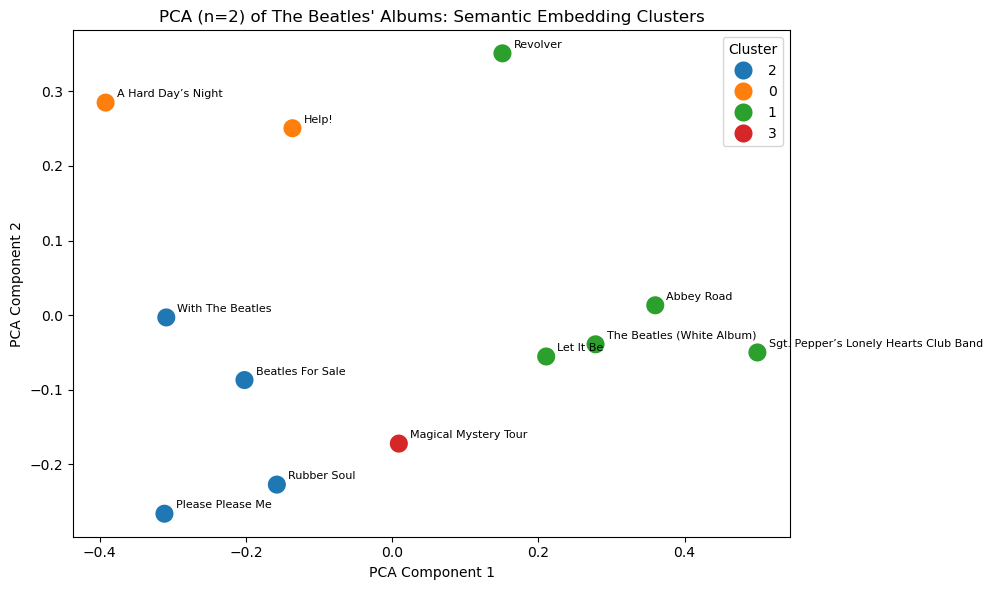

In [85]:
# Semantic embedding PCA plotting.
pca_semantic = PCA(n_components=2)
reduced_semantic = pca_semantic.fit_transform(vector_matrix)

semantic_df = pd.DataFrame({
    'Album': album_order, 
    'PCA1': reduced_semantic[:, 0], 
    'PCA2': reduced_semantic[:, 1], 
    'Cluster': semantic_clusters.astype(str)
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=semantic_df, x='PCA1', y='PCA2', hue='Cluster', s=200)

for idx, row in semantic_df.iterrows():
    plt.annotate(row['Album'], (row['PCA1'], row['PCA2']),
                 fontsize=8, xytext=(8, 4), textcoords='offset points')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA (n=2) of The Beatles' Albums: Semantic Embedding Clusters")
plt.tight_layout()
plt.show()

##### *Observations:* 
* Cluster 0 (orange cluster: A Hard Day's Night, and Help!) stand apart with everything else, sitting high and to the left.
* Cluster 1 (green cluster: Let It Be, Revolver, The Beatles (White Album), Sgt. Pepper's Lonely Hearts Club Band, Abbey Road) semantically groups the majority of the later Beatles albums together. 
* Cluster 2 (blue cluster: Please Please Me, Rubber Soul, Beatles For Sale, and With The Beatles) represent the group's early-to-mid releases.
* Cluster 3 (red cluster): once again, belongs to the isolated album, Magical Mystery Tour.

##### *Analysis:*
The semantic embedding plot reflects the thematic evolution of the Beatles. The biggest cluster (cluster 1) groups the majority of the Beatles' later releases together. This suggests that despite their varying stylistic differences, these albums share similar meanings in their themes and ideas. 

A Hard Day's Night and Help! forming their standalone cluster is notable. Both are albums tied to films. This may explain their distinct semantic profiles from the rest of their catalog. 


Cluster 2 can suggest a shared world of romantic longing and everyday emotion that's consistent with their songwriting during that specific, early-to-mid Beatles period.


Magical Mystery Tour continues to stand by itself in clustering as it is the most semantically distinct album. Its themes and ideas are unlike anything the Beatles have done anywhere else in their discography.  

This is all very interesting, but let's put the PCA plots of tf-idf as well as the semantic embeddings side-by-side, and draw more conclusions from their comparisons.

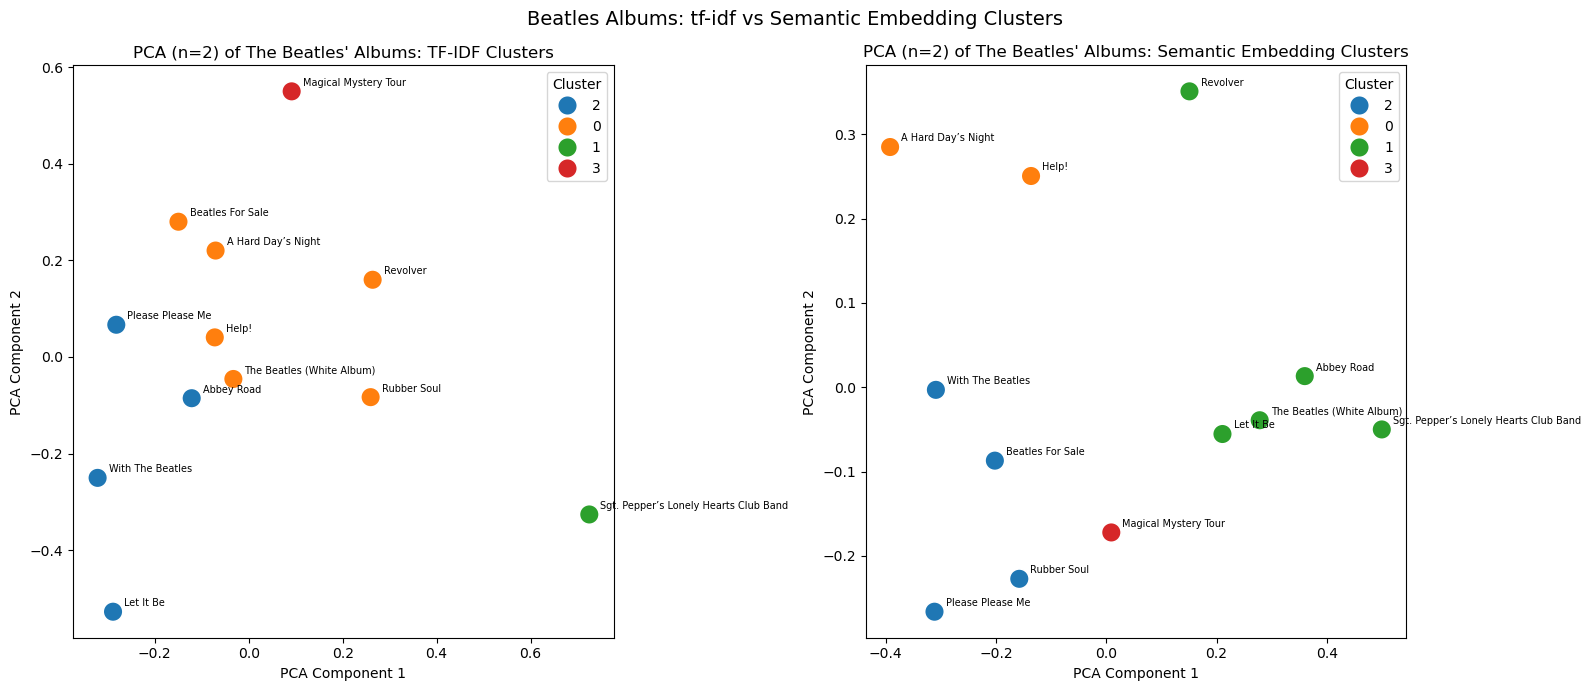

In [86]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: tf-idf plot.
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', s=200, ax = ax1)
for idx, row in pca_df.iterrows():
    ax1.annotate(row['Album'], (row['PCA1'], row['PCA2']),
                 fontsize=7, xytext=(8, 4), textcoords='offset points')
ax1.set_xlabel("PCA Component 1")
ax1.set_ylabel("PCA Component 2")
ax1.set_title("PCA (n=2) of The Beatles' Albums: TF-IDF Clusters")

# Right: Semantic embedding plot.
sns.scatterplot(data=semantic_df, x='PCA1', y='PCA2', hue='Cluster', s=200, ax=ax2)
for idx, row in semantic_df.iterrows():
    ax2.annotate(row['Album'], (row['PCA1'], row['PCA2']),
                 fontsize=7, xytext=(8, 4), textcoords='offset points')
ax2.set_xlabel("PCA Component 1")
ax2.set_ylabel("PCA Component 2")
ax2.set_title("PCA (n=2) of The Beatles' Albums: Semantic Embedding Clusters")

plt.suptitle("Beatles Albums: tf-idf vs Semantic Embedding Clusters", fontsize=14)
plt.tight_layout()
plt.show()



##### *Observations:* 
In the tf-idf clustering plot, Sgt. Pepper's is the biggest outlier (far right), but sits comfortably with the Beatles' later releases in the semantic embedding clustering plot. Magical Mystery Tour consistently shows up in both plots as its own isolated cluster. The early albums (Please Please Me, With The Beatles) form one cluster with later Beatles releases (Abbey Road, Let It Be), but seperate cleanly in the semantic plot. A Hard Day's Night and Help! continue to cluster together in both plots. 

##### *Analysis:*
The side-by-side comparison helps illustrate where the two methods agree and where they diverge. Both plots continously isolate Magical Mystery Tour. Regardless of what we're measuring, it sits as their most distinct album in their catalog. 

The most significant divergence appears to be with Sgt. Pepper's Lonely Hearts Club Band. The tf-idf plot places it as an outlier in the entire corpus, but the semantic plot pulls it into the later record releases (Cluster 1). This reveals that Sgt. Pepper's may use unusual and unique vocabulary, but the meaning underneath the lyrics are not very different from the albums that follow it. 

The combination of early/later album releases in the tf-idf plot also dissolves in the semantic plot: earlier releases are distinctly more separated from later releases. This can suggest that although early and later Beatles albums may share similar vocabulary, they aren't really conveying the same ideas. The genuine thematic difference only emerges when meaning is taken into account.

## Close Readings

The close readings are supposed to track some of the striking moments in the Beatles' evolving musical arcs. I'd like to do some close readings on specific, individual songs that can explain what the data has shown so far. 

In [79]:
# Compute TTR per individual song.
song_ttr = []
for album_name, song in songs:
    if song['lyrics']:
        cleaned = clean_lyrics(song['lyrics'])
        words = cleaned.split()
        if len(words) > 0:
            tokens = len(words)
            types = len(set(words))
            ttr = round(types / tokens, 4)
            song_ttr.append({'Album': album_name, 'Song': song['title'], 'Tokens': tokens, 'Types': types, 'TTR': ttr})

song_ttr_df = pd.DataFrame(song_ttr)
song_ttr_df

,Album,Song,Tokens,Types,TTR
0,Please Please Me,I Saw Her Standing There,121,58,0.4793
1,Please Please Me,Misery,85,43,0.5059
2,Please Please Me,Anna (Go to Him),135,50,0.3704
3,Please Please Me,Chains,115,48,0.4174
4,Please Please Me,Boys,232,43,0.1853
...,...,...,...,...,...
173,Let It Be,I’ve Got a Feeling,223,64,0.2870
174,Let It Be,One After 909,184,53,0.2880
175,Let It Be,The Long and Winding Road,95,49,0.5158
176,Let It Be,For You Blue,81,45,0.5556


In [83]:
#defining chronological order. 
album_order = [
    "Please Please Me", "With The Beatles", "A Hard Day’s Night",
    "Beatles For Sale", "Help!", "Rubber Soul", "Revolver",
    "Sgt. Pepper’s Lonely Hearts Club Band", "Magical Mystery Tour",
    "The Beatles (White Album)", "Abbey Road", "Let It Be"
]

# Most lexically diverse song per album.
most_diverse = song_ttr_df.loc[song_ttr_df.groupby('Album')['TTR'].idxmax()]
most_diverse = most_diverse.set_index('Album').loc[album_order].reset_index()
print("\nMost lexically diverse song per album:\n")
display(most_diverse[['Album', 'Song', 'TTR']])

# Most repetitive song per album.
most_repetitive = song_ttr_df.loc[song_ttr_df.groupby('Album')['TTR'].idxmin()]
most_repetitive = most_repetitive.set_index('Album').loc[album_order].reset_index()
print("\nMost repetitive song per album:\n")
display(most_repetitive[['Album', 'Song', 'TTR']])


Most lexically diverse song per album:



,Album,Song,TTR
0,Please Please Me,Misery,0.5059
1,With The Beatles,Roll Over Beethoven,0.5951
2,A Hard Day’s Night,And I Love Her,0.5536
3,Beatles For Sale,I’m a Loser,0.6186
4,Help!,You’ve Got to Hide Your Love Away,0.6622
5,Rubber Soul,Norwegian Wood (This Bird Has Flown),0.8281
6,Revolver,Love You To,0.7571
7,Sgt. Pepper’s Lonely Hearts Club Band,Being for the Benefit of Mr. Kite!,0.7549
8,Magical Mystery Tour,Penny Lane,0.6343
9,The Beatles (White Album),I Will,0.7910



Most repetitive song per album:



,Album,Song,TTR
0,Please Please Me,Twist and Shout,0.1667
1,With The Beatles,I Wanna Be Your Man,0.1351
2,A Hard Day’s Night,Can’t Buy Me Love,0.3007
3,Beatles For Sale,Kansas City/Hey-Hey-Hey-Hey!,0.2067
4,Help!,You’re Going to Lose That Girl,0.1674
5,Rubber Soul,Wait,0.2817
6,Revolver,She Said She Said,0.2672
7,Sgt. Pepper’s Lonely Hearts Club Band,Lovely Rita,0.3548
8,Magical Mystery Tour,"Hello, Goodbye",0.1370
9,The Beatles (White Album),Wild Honey Pie,0.1579


### 1. "I Wanna Be Your Man" (Please Please Me)

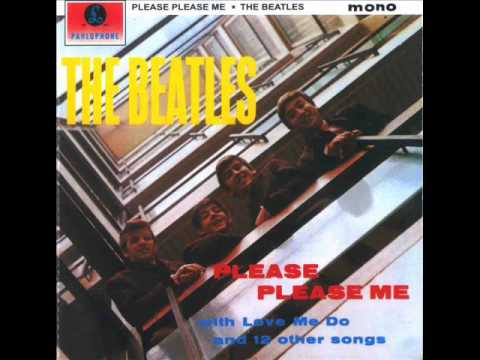

In [84]:
YouTubeVideo('r83yZkoeS5w', width=500, height=300)

"Twist and Shout" has the lowest TTR (0.1667) on the Beatles' first album, Please Please Me, and among the lowest in the entire corpus. This is consistent with its structures as its almost entirely a repetition of iterative commands: 'twist and shout', 'work it on out', etc. Every verse recycles the same phrases with minimal variation. This produces a high token count, but narrow type count. 

This song wasn't written for The Beatles originally though. Like a lot of the songs on The Beatles first few records, it's a cover. Originally recorded by the Isley Brothers, it's rooted in an R&B tradition of call-and-response. The low TTR is therefore not a reflection of the band's own songwriting, but a feature of the genre they were pulling from. The distinction matters. The low lexical diversity of the Beatles' earlier catalog is not a sign of limited songwriting ambition, but a popular adoption of a musical tradition. 

### 2. "Norwegian Wood (This Bird Has Flown)" (Rubber Soul)

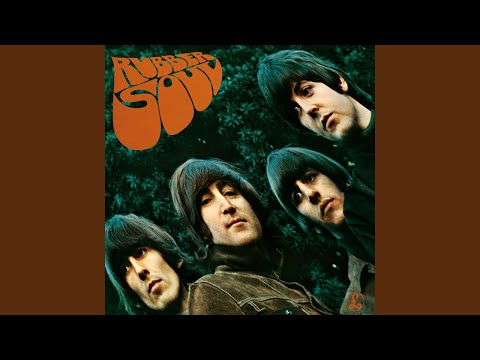

In [19]:
YouTubeVideo('v56Zc8ZYbeE', width=500, height=300)

"Norwegian Wood (This Bird Has Flown)" has the highest lexical diversity of any of their pre-experimental albums in the corpus (as well as the second-highest TTR overall). Almost every line introduces something new like vocabulary, imagery, or narrative beat. The song tells a complete story in under two minutes or less. A narrator visits a woman, they talk until two in the morning, she goes to bed while he sleeps in the bath, then he wakes up alone. The compression alone demands lexical variety. 

What makes the song noticable is that the diversity suggests a transitional shift in the Beatles' songwriting. The lyrics are ambiguous as illustrated by the opening lines, "I once had a girl / Or should I say, she once had me?" that mark a clear turning point. Their early catalog demonstrated a more transparent emotional situation, but now they're going into deeper lyrical exploration. This transitional phase will help in shaping what will eventually be their most experimental releases later on. 

### 3. "Being for the Benefit of Mr. Kite!" (Sgt. Pepper’s Lonely Hearts Club Band)

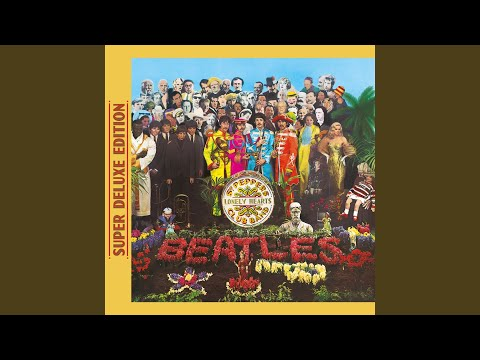

In [87]:
YouTubeVideo('TJNndwGFJIM', width=500, height=300)

"Being for the Benefit of Mr. Kite!" is the most lexically diverse song on the most TF-IDF distinct album in the corpus. Nearly every lyric introduces vocabulary that is not apparent anywhere else in their catalog: "garters", "hogshead", "Pablo Fanque", "Bishopsgate", and so forth. This can explain Sgt. Pepper's isolation on the tf-idf clustering plot. When looking into the creation behind the song, its unique words are directly lifted from a Victorian circus poster John Lennon found at an antique shop. (https://faroutmagazine.co.uk/the-poster-that-inspired-the-beatles-mr-kite/) The song's TTR is a direct result of its source material being a century removed from the language of 1960s popular music. 

Structurally, the lyrics don't contain any emotional address. The song seems to function as a big, third-person announcement. This is a big departure from their early works where there was a direct emotional address, illustrating how far the Beatles moved from writing about personal feeling toward constructing melodic worlds not drawn entirely from their own experience. 

In [ ]:
#lyric checking for close readings. 
def get_song_lyrics(song_title):
    for album_name, song in songs:
        if song['title'].lower() == song_title.lower():
            print(f"Album: {album_name}")
            print(song['lyrics'])
            return song['lyrics']
    print(f"Not found: {song_title}")

get_song_lyrics("I am The Walrus") 

### 4. "I Want You (She’s So Heavy)" (Abbey Road)

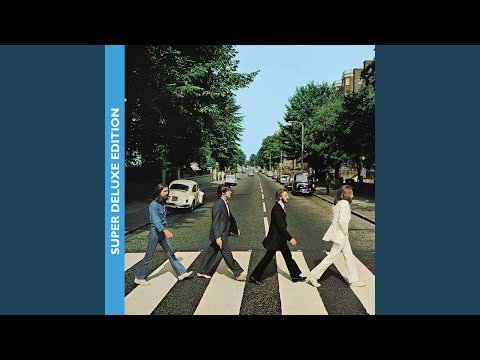

In [26]:
YouTubeVideo('wNL6bd7SpDE', width=500, height=300)

"I Want You (She’s So Heavy)" is the most repetitive song in the entire catalog (corpus) with a TTR of 0.1183. The song does not contain that many words, cycling through "I want you so bad" and "It's driving me mad" across nearly 8 minutes of music. For an album that registers one of the highest TTRs in their catalog, this song is a striking outlier. There is a separation between the repetition displayed here and the repetition seen in a song like, "Twist and Shout." While the early Beatles' repetition referenced the R&B call-and-response tradition, the repetition here is deliberate and psychologically unerving. The lyrics don't build towards anything. It repeats, accumulates, then cuts off mid-phrase in the song's final seconds. It gives off a suffocating, unresolved nature. 

This song makes a good counterargument to a straightforward reading of the TTR data. High lexical diversity of an album does not mean every song was more complex. It means the Beatles developed enough control over their language use to deploy repetition as a conscious artistic choice rather than a structural genre convention. 

### [bonus] 5. "I Am the Walrus" (Magical Mystery Tour)

Although none of the songs from Magical Mystery Tour stood out as very analytically interesting in either the 'most diverse' or 'most repetitive' song tables, I feel the need to spotlight a song from the album regardless because of how much individuality the album displayed throughout my analyses. The close readings are supposed to represent key moments in their musical arcs, and Magical Mystery Tour, to me, is too weird to ignore. 

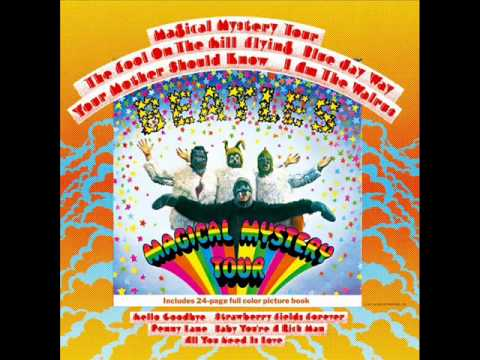

In [94]:
YouTubeVideo('AuCei9uVVd4', width=500, height=300)

"I Am The Walrus" doesn't show up in either of my two tables for the most repetitive nor lexically diverse Beatles song per album, but I'm covering it anyways because it deserves the recognition. 

"I Am The Walrus" is the most linguistically extreme song in the Beatles' discography, and illustrates why Magical Mystery Tour dips in TTR despite its experimental reputation. Its imagery is wildly diverse. The verses contain phrases like, "Yellow-matter custard" and "Crabalocker fishwife, pornographic priestess". The inventiveness is mostly concentrated in the verses, with the chorus having little semantic content whatsoever (unless there is meaning I'm missing with "I am the egg man" and "G'goo goo g'joob"). The contrast between the surrealist vocabulary and the nonsense repetition in this song can illustrate the album's TTR dip the best. The nonsense phrases inflate the type count while the repeated bridge of "joob joob joob" drives the token count up without adding any new vocabulary to the mix. 

The outro's also notable for its inclusion of a live radio broadcast of the Shakespeare production, King Lear (https://faroutmagazine.co.uk/the-beatles-song-that-accidentally-sampled-william-shakespeare/). The song pulls text from canonical English literature to add a layer underneath the Beatles nonsensical imagery. The song is not one coherent text but several sources colliding intensely together, which is consistent with Magical Mystery Tour's isolation in both clustering plots. Its language is not only unusual in its vocabulary, but unusual in its constructed composition. 

## Conclusion 

This project set out to examine whether the Beatles' stylistic and thematic evolution is reflected in the changes in their language use across their studio discography. The findings suggest that it is.

The TTR analysis confirms that lexical diversity increased over time. Early albums were built largely on a lot of cover songs that contained the R&B tradition of call-and-response, which caused the type-token ratios to be low compared to later releases that had higher type-token ratios. The tf-idf clustering identifies Sgt. Pepper's Lonely Hearts Club Band and Magical Mystery Tour as the most lexically distinct in their catalog (that do not have enough similar terminology to cluster with other albums). The semantic word embedding analysis adds another layer to the Beatles' language use. While Sgt. Pepper's is lexically distinct on the surface, it shares similar thematic territory with other later albums. This suggests its experimentation was more vocabulary-based rather than conceptual. 

The close readings help ground my findings into actual lyrics. "Twist and Shout" demonstrates the early repetition inherited from genre convention rather than limited songwriting ambition. "Norwegian Wood" marks the turning point for the band: a quick, introductory glimpse of narrative ambiguity that would continue to be explored in the Beatles' music journey. "Being for the Benefit of Mr. Kite!" shows that the high lexical diversity in the Sgt. Pepper's album was not always the Beatles writing in a new voice, but words borrowed from an external source that delivered lyrical inspiration. "I Want You (She's So Heavy)" and "I Am the Walrus" represents the deliberate artistic choices the band made with repetition and surrealism. The early Beatles records reflected the genre's musical landscape demands, but later Beatles records reflects the artistic expedition they undertook. 

There are, of course, limitations worth acknowledging. The corpus relies on Genius transcriptions, which may contain errors or inconsistencies across songs. The spaCy embeddings were useful, but were trained on general English rather than Beatles-specific language. So, idiosyncratic phrases like "Goo goo goo joob" are unlikely to be represented meaningfully (if there's any meaning to be represented at all...) in the vector space. Clustering is also sensitive to the number of clusters chosen. I used my best judgement, but different values of k will produce different groupings. 

Despite these limitations, these multiple methods converge to meet a similar conclusion: the Beatles' language use changed in ways that are both significant and meaningful. From structured beginnings to their eventual dissolution, these changes track closely with their artistic evolution. 